In [18]:
%pip install ultralytics scikit-learn seaborn matplotlib pandas opencv-python -q

from ultralytics import YOLO
import cv2
import numpy as np
import time
import os

modelo = YOLO("yolov8m.pt")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# area da fila
ROI_X1 = 100
ROI_Y1 = 100
ROI_X2 = 900
ROI_Y2 = 900

In [20]:
def contar_pessoas(imagem, gt=None):
    """
    Conta pessoas dentro da ROI em uma imagem ou frame de vídeo.
    Para vídeo em tempo real use model.track(); esta função usa predict()
    para funcionar corretamente em imagens estáticas.
    """
    inicio = time.time()

    resultados = modelo.predict(
        source=imagem,
        classes=[0],
        conf=0.35,
        imgsz=1280,
        verbose=False,
    )

    tempo_processamento = time.time() - inicio
    frame_saida = resultados[0].plot()

    cv2.rectangle(
        frame_saida,
        (ROI_X1, ROI_Y1),
        (ROI_X2, ROI_Y2),
        (255, 0, 0),
        2,
    )

    ids_contados = 0
    confiancas = []

    boxes_xyxy = resultados[0].boxes.xyxy.cpu().numpy()
    confs = resultados[0].boxes.conf.cpu().numpy()

    for box, conf in zip(boxes_xyxy, confs):
        x1, y1, x2, y2 = box
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2

        if ROI_X1 <= cx <= ROI_X2 and ROI_Y1 <= cy <= ROI_Y2:
            ids_contados += 1
            confiancas.append(float(conf))

    estatisticas = {
        "quantidade": ids_contados,
        "confiancas": confiancas,
        "tempo_processamento": tempo_processamento,
        "ground_truth": gt,
    }

    return ids_contados, frame_saida, estatisticas

In [21]:
# Defina os caminhos das suas imagens locais e o ground truth (nº real de pessoas)
imagens_teste = [
    ("imagens-teste/fila1.jpg", 12),
    ("imagens-teste/fila2.jpg", 6),
    ("imagens-teste/fila3.jpg", 5),
]

for caminho, gt in imagens_teste:
    if not os.path.exists(caminho):
        print(f"[AVISO] Imagem não encontrada: {caminho} — pulando.")
        continue
    quantidade, frame, stats = contar_pessoas(caminho, gt=gt)
    print(f"{caminho} — Detectado: {quantidade} | Real informado: {stats['ground_truth']}")

imagens-teste/fila1.jpg — Detectado: 11 | Real informado: 12
imagens-teste/fila2.jpg — Detectado: 5 | Real informado: 6
imagens-teste/fila3.jpg — Detectado: 4 | Real informado: 5


In [22]:
from ultralytics import YOLO

modelo = YOLO("yolov8m.pt")

modelo.export(format="onnx")


Ultralytics 8.4.72  Python-3.12.6 torch-2.12.1+cpu CPU (AMD Ryzen 5 5600X 6-Core Processor)
YOLOv8m summary (fused): 92 layers, 25,886,080 parameters, 0 gradients, 78.9 GFLOPs

PyTorch: starting from 'yolov8m.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (49.7 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  2.5s, saved as 'yolov8m.onnx' (99.0 MB)

Export complete (3.3s)
Results saved to C:\Users\Nicolas\Desktop\Projetos\PESSOAL\Contador-de-pessoas-com-YOLO\yolov8m.onnx
Predict:         yolo predict task=detect model=yolov8m.onnx imgsz=640 
Validate:        yolo val task=detect model=yolov8m.onnx imgsz=640 data=coco.yaml  
Visualize:       https://netron.app


'yolov8m.onnx'

Pessoas na fila: 5
Tempo de processamento: 1.034s
Confiança média: 0.898


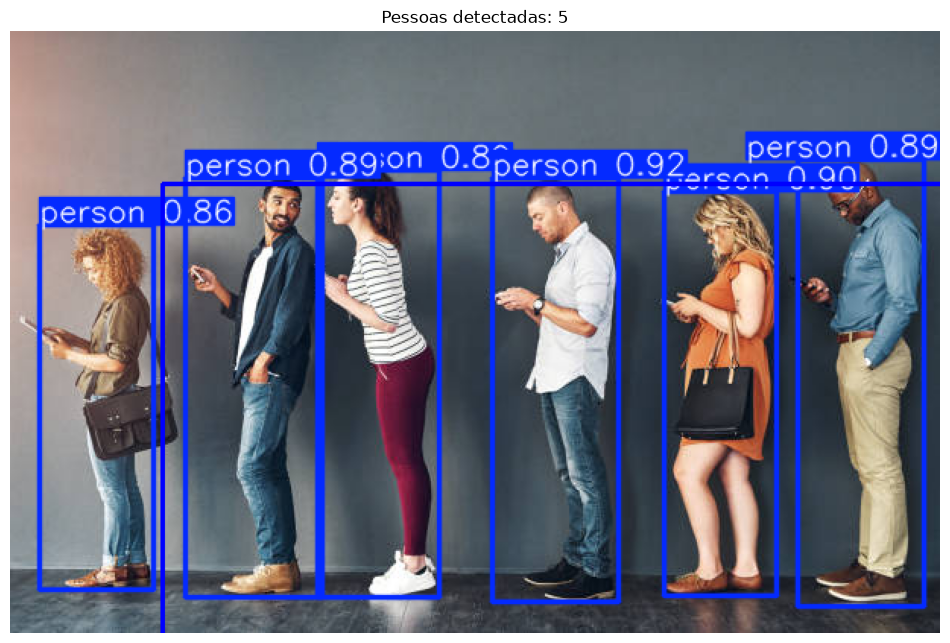

In [23]:
import matplotlib.pyplot as plt

# Altere para o caminho da imagem que você quer testar
caminho_imagem = "imagens-teste/fila2.jpg"

imagem = cv2.imread(caminho_imagem)
if imagem is None:
    raise FileNotFoundError(f"Imagem não encontrada: {caminho_imagem}")

quantidade, frame_anotado, estatisticas = contar_pessoas(imagem)

print(f"Pessoas na fila: {quantidade}")
print(f"Tempo de processamento: {estatisticas['tempo_processamento']:.3f}s")
if estatisticas['confiancas']:
    print(f"Confiança média: {sum(estatisticas['confiancas'])/len(estatisticas['confiancas']):.3f}")

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(frame_anotado, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"Pessoas detectadas: {quantidade}")
plt.show()